In [1]:
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

df = pd.read_csv(
    "amazon_cells_labelled.txt",
    sep="\t",
    header=None,
    names=["text", "label"]
)

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

train_end = int(0.7 * len(df))
val_end   = int(0.85 * len(df))

train = df.iloc[:train_end]
val   = df.iloc[train_end:val_end]
test  = df.iloc[val_end:]

X_train, y_train = train["text"], train["label"]
X_val,   y_val   = val["text"],   val["label"]
X_test,  y_test  = test["text"],  test["label"]

2025-12-17 17:34:53.288310: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-17 17:34:53.296302: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-17 17:34:53.317646: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765989293.350741 3033819 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765989293.360815 3033819 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-12-17 17:34:53.400148: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

In [2]:
def create_datasets(model, max_tokens, max_len, batch_size, loss, optimizer):
    y_tr = y_train
    y_v = y_val
    y_te = y_test
    if loss == "hinge":
        y_tr = y_tr.map(lambda x: 1 if x == 1 else -1)
        y_v = y_v.map(lambda x: 1 if x == 1 else -1)
        y_te = y_te.map(lambda x: 1 if x == 1 else -1)
    vectorize = layers.TextVectorization(
        max_tokens=max_tokens,
        output_mode="int",
        output_sequence_length=max_len
    )

    vectorize.adapt(X_train.values)
    
    def make_ds(texts, labels):
        ds = tf.data.Dataset.from_tensor_slices((texts, labels))
        ds = ds.batch(batch_size).map(lambda x, y: (vectorize(x), y))
        return ds.prefetch(tf.data.AUTOTUNE)
        
    train_ds = make_ds(X_train.values, y_tr.values)
    val_ds   = make_ds(X_val.values,   y_v.values)
    test_ds  = make_ds(X_test.values,  y_te.values)
    
    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=["accuracy"]
    )
    
    model.summary()
    return train_ds, val_ds, test_ds

In [3]:
def use_model(name, epochs, model, train_ds, val_ds, test_ds):
    folder = "images/"
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs
    )
    model.summary()
    test_loss, test_acc = model.evaluate(test_ds)
    print("Test accuracy:", test_acc)
    print("Test loss:", test_loss)
    history_dict = history.history
    
    loss = history_dict["loss"]
    val_loss = history_dict["val_loss"]
    epochs = range(1, len(loss) + 1)
    
    plt.figure(figsize=(6,4))
    plt.plot(epochs, loss, "bo-", label="Training loss")
    plt.plot(epochs, val_loss, "ro-", label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and validation loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(folder + name + "_loss.png", dpi=150)   # uloží obrázek
    plt.show()

    acc = history_dict["accuracy"]
    val_acc = history_dict["val_accuracy"]
    
    plt.figure(figsize=(6,4))
    plt.plot(epochs, acc, "bo-", label="Training accuracy")
    plt.plot(epochs, val_acc, "ro-", label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and validation accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(folder + name + "_accuracy.png", dpi=150)
    plt.show()

    return test_loss, test_acc

In [4]:
import time

model_data = []
default_activation="relu"

def run(
    name,
    optimizer="adam",
    activation=default_activation,
    loss="binary_crossentropy",
    main_layers=[layers.GlobalAveragePooling1D()],
    extra_layers=None,
    max_tokens=10000,
    max_len=40,
    epochs=10,
    batch_size=32
):
    if extra_layers is None:
        extra_layers = [layers.Dense(64, activation=activation)]
    start = time.time()  
    print(f"-> Model {name}")
    model = keras.Sequential([
        layers.Embedding(input_dim=max_tokens, output_dim=64, input_length=max_len)
    ] + main_layers + extra_layers + [
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid")
    ])
    train_ds, val_ds, test_ds = create_datasets(model, max_tokens=max_tokens, max_len=max_len, batch_size=batch_size, loss=loss, optimizer=optimizer)
    loss, acc = use_model(name, epochs, model, train_ds, val_ds, test_ds)
    end = time.time()
    took = end - start
    print(f"<- Model {name} took {took}ms")
    model_data.append({"name": name, "time": took, "loss": loss, "acc": acc})
    # 3 empty lines to separate models
    for _ in range(3):
        print()

-> Model default


/opt/tljh/user/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2025-12-17 17:34:57.104471: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

...

 Total params: 1,932,677 (7.37 MB)

 Trainable params: 644,225 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,288,452 (4.92 MB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7463 - loss: 0.5753
Test accuracy: 0.753333330154419
Test loss: 0.5689508318901062


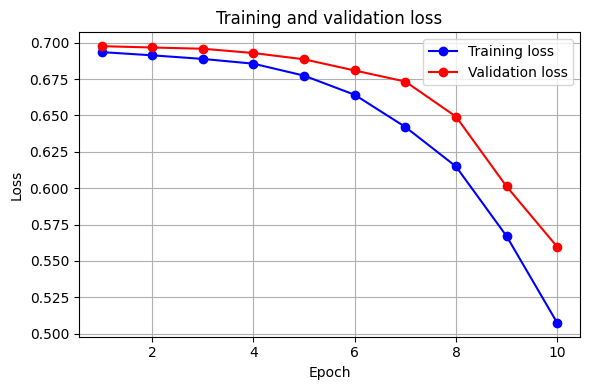

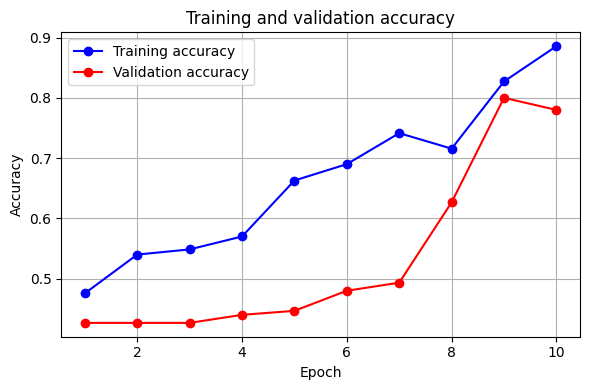

<- Model default took 8.450930833816528ms



-> Model 5-epochs


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 1,932,677 (7.37 MB)

 Trainable params: 644,225 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,288,452 (4.92 MB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5168 - loss: 0.6831
Test accuracy: 0.5400000214576721
Test loss: 0.6814519166946411


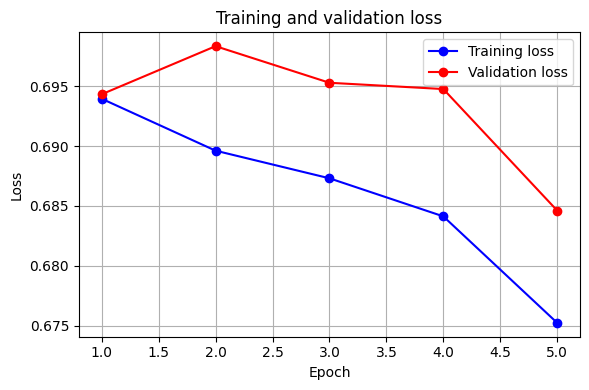

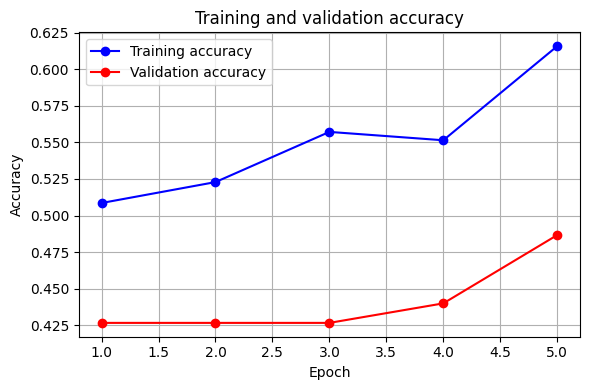

<- Model 5-epochs took 5.818025827407837ms



-> Model 20-epochs


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 1,932,677 (7.37 MB)

 Trainable params: 644,225 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,288,452 (4.92 MB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7747 - loss: 0.4516
Test accuracy: 0.7733333110809326
Test loss: 0.4549626111984253


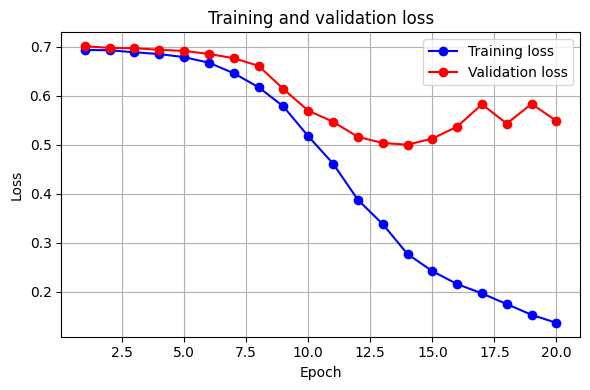

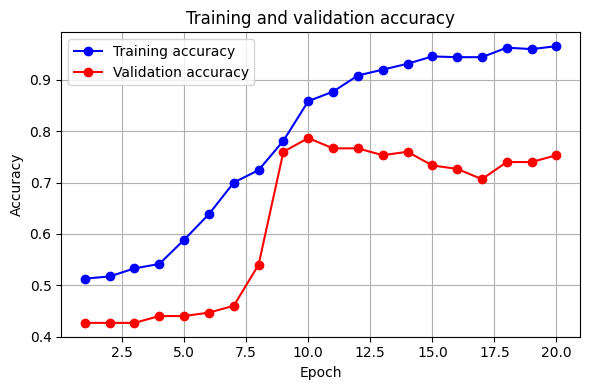

<- Model 20-epochs took 12.920495510101318ms



-> Model 16-batches


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 1,932,677 (7.37 MB)

 Trainable params: 644,225 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,288,452 (4.92 MB)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7974 - loss: 0.4391 
Test accuracy: 0.800000011920929
Test loss: 0.4366733431816101


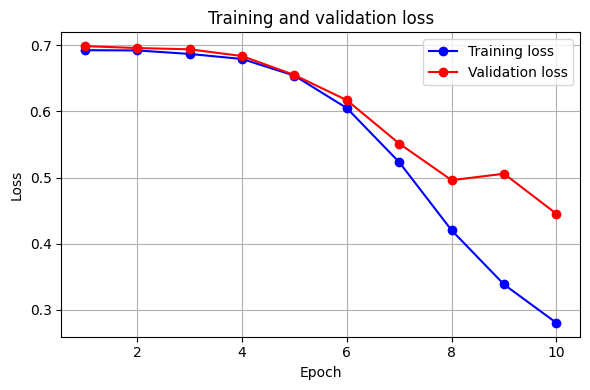

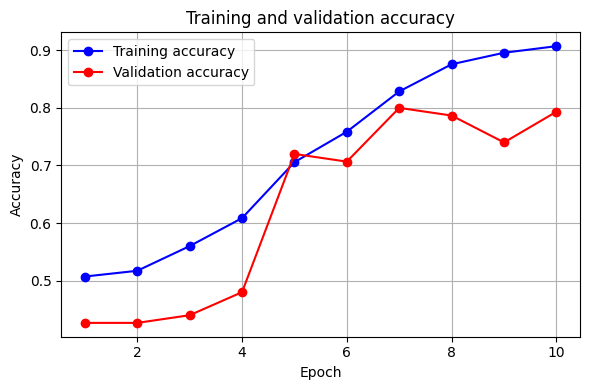

<- Model 16-batches took 11.513806581497192ms



-> Model 64-batches


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 1,932,677 (7.37 MB)

 Trainable params: 644,225 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,288,452 (4.92 MB)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6759 - loss: 0.6559
Test accuracy: 0.6800000071525574
Test loss: 0.6540306210517883


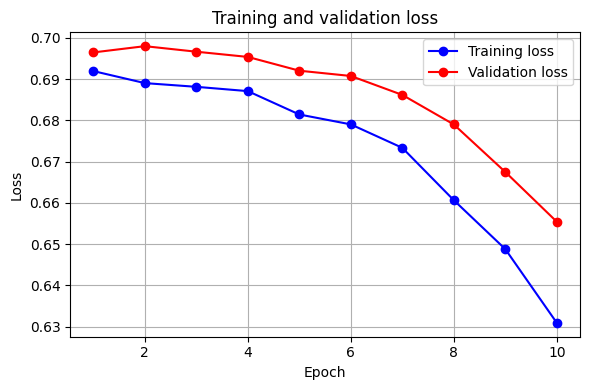

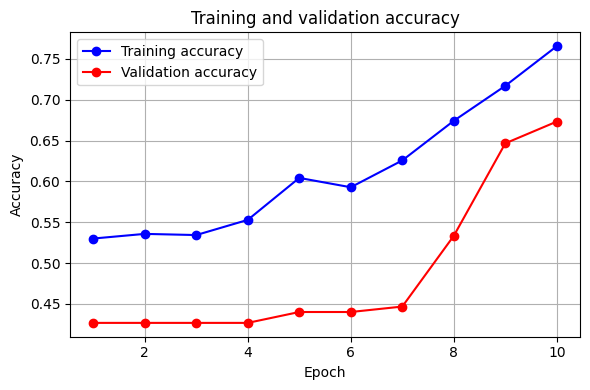

<- Model 64-batches took 7.038062334060669ms



-> Model model_a


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 1,920,197 (7.32 MB)

 Trainable params: 640,065 (2.44 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,280,132 (4.88 MB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5737 - loss: 0.6736
Test accuracy: 0.6000000238418579
Test loss: 0.6709125638008118


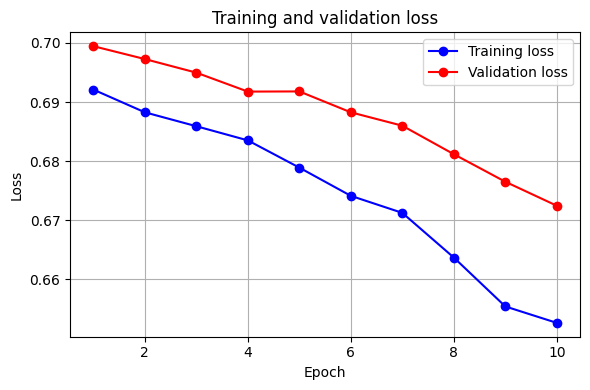

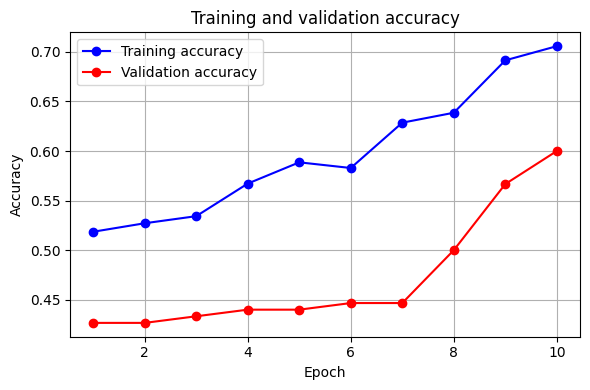

<- Model model_a took 7.929649353027344ms



-> Model model_c


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 1,957,829 (7.47 MB)

 Trainable params: 652,609 (2.49 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,305,220 (4.98 MB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7904 - loss: 0.4272
Test accuracy: 0.7866666913032532
Test loss: 0.4315733313560486


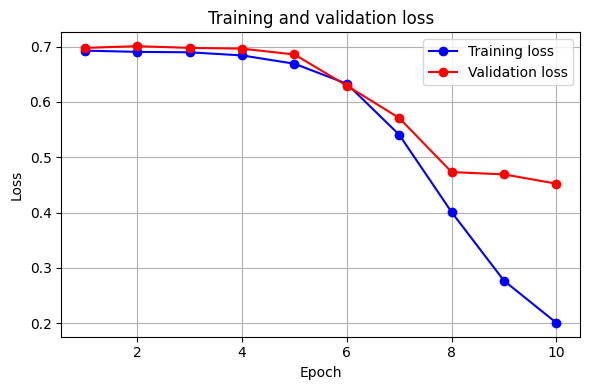

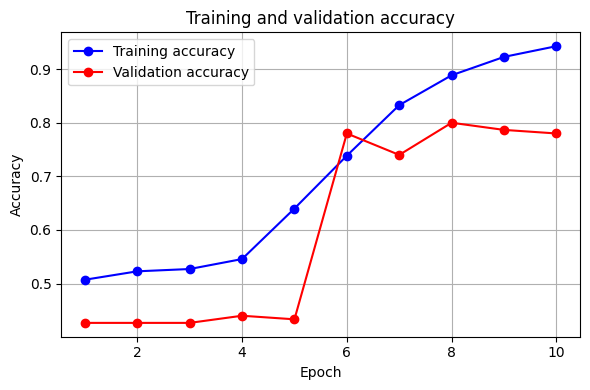

<- Model model_c took 8.531960725784302ms



-> Model 1d_cnn


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 1,969,733 (7.51 MB)

 Trainable params: 656,577 (2.50 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,313,156 (5.01 MB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8001 - loss: 0.3711
Test accuracy: 0.8066666722297668
Test loss: 0.3978036940097809


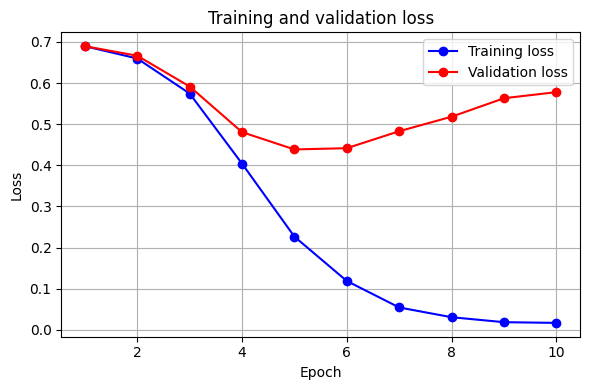

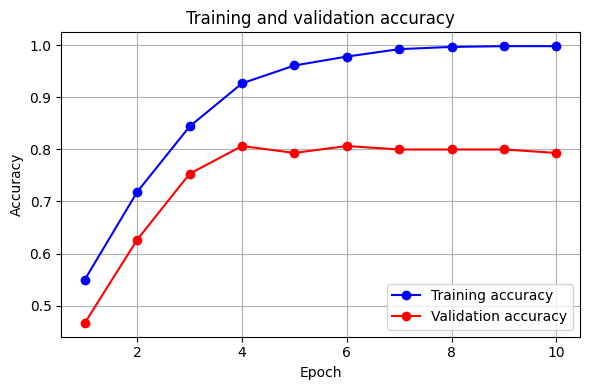

<- Model 1d_cnn took 9.650461435317993ms



-> Model tanh


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 1,932,677 (7.37 MB)

 Trainable params: 644,225 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,288,452 (4.92 MB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7568 - loss: 0.5325
Test accuracy: 0.753333330154419
Test loss: 0.5254898071289062


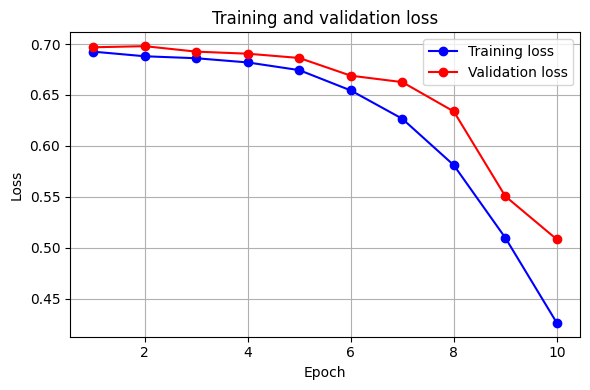

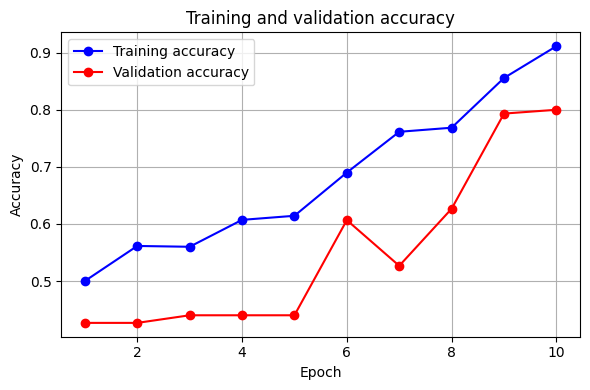

<- Model tanh took 8.399146556854248ms



-> Model hinge


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 1,932,677 (7.37 MB)

 Trainable params: 644,225 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,288,452 (4.92 MB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4607 - loss: 1.0309
Test accuracy: 0.47333332896232605
Test loss: 1.0119928121566772


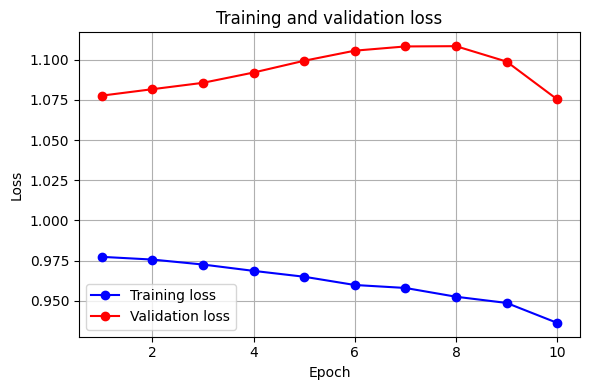

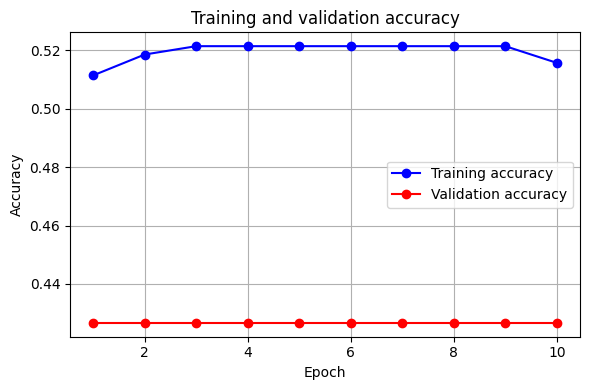

<- Model hinge took 7.692604303359985ms



-> Model sgd


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 1,288,452 (4.92 MB)

 Trainable params: 644,225 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 644,227 (2.46 MB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4607 - loss: 0.6969
Test accuracy: 0.47333332896232605
Test loss: 0.6957579255104065


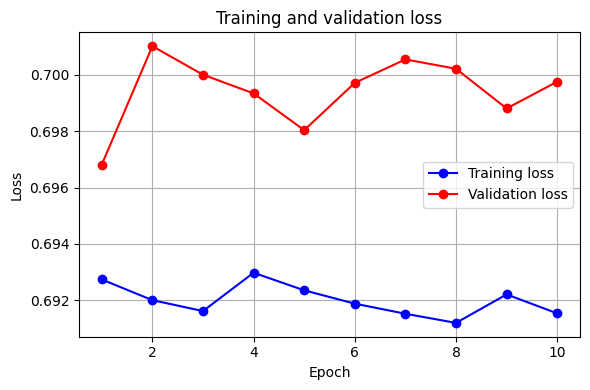

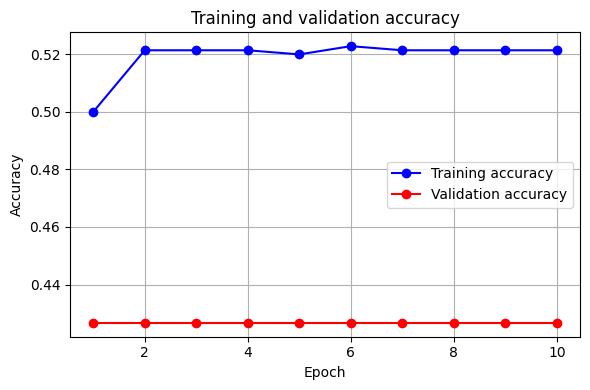

<- Model sgd took 5.46558403968811ms



-> Model rmsprop


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

 Total params: 1,288,452 (4.92 MB)

 Trainable params: 644,225 (2.46 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 644,227 (2.46 MB)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4607 - loss: 0.6948
Test accuracy: 0.47333332896232605
Test loss: 0.6932787895202637


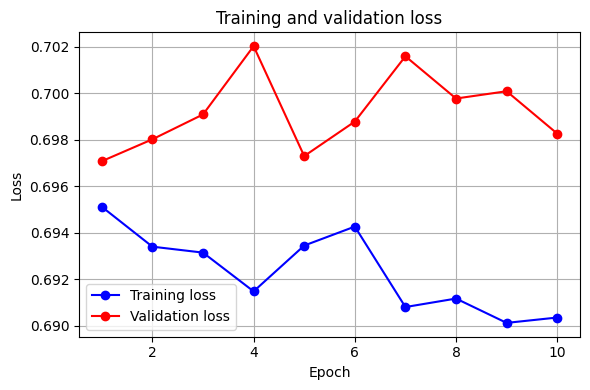

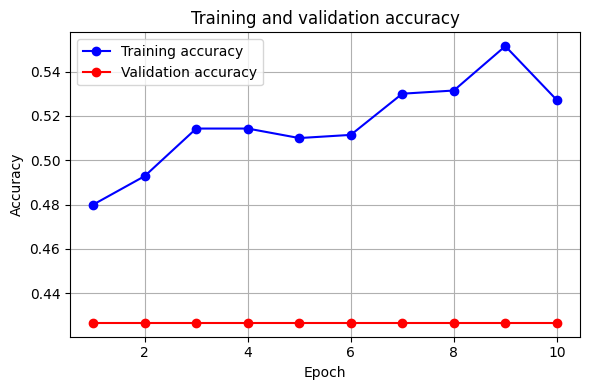

<- Model rmsprop took 6.707908391952515ms



[{'name': 'default', 'time': 8.450930833816528, 'loss': 0.5689508318901062, 'acc': 0.753333330154419}, {'name': '5-epochs', 'time': 5.818025827407837, 'loss': 0.6814519166946411, 'acc': 0.5400000214576721}, {'name': '20-epochs', 'time': 12.920495510101318, 'loss': 0.4549626111984253, 'acc': 0.7733333110809326}, {'name': '16-batches', 'time': 11.513806581497192, 'loss': 0.4366733431816101, 'acc': 0.800000011920929}, {'name': '64-batches', 'time': 7.038062334060669, 'loss': 0.6540306210517883, 'acc': 0.6800000071525574}, {'name': 'model_a', 'time': 7.929649353027344, 'loss': 0.6709125638008118, 'acc': 0.6000000238418579}, {'name': 'model_c', 'time': 8.531960725784302, 'loss': 0.4315733313560486, 'acc': 0.7866666913032532}, {'name': '1d_cnn', 'time': 9.650461435317993, 'loss': 0.3978036940097809, 'acc': 0.8066666722297668}, {'name': 'tanh', 'time': 8.399146556854248, 'loss': 0.5254898071289062, 'acc': 0.753333330154419}, {'name': 'hinge', 'time

In [5]:
run("default")

# Různé počty epoch
## reference: 10 epochs
## default

## zda se model učí už na začátku.
run("5-epochs", epochs=5)

## zda začne přeučení (val_loss začne růst).
run("20-epochs", epochs=20)

# Různé počty batch_size
## reference: 32 batches
## default

## menší batch → více update kroků, často lepší generalizace, ale pomalejší.
run("16-batches", batch_size=16)

## větší batch → rychlejší epochy, ale model se může učit hůř.
run("64-batches", batch_size=64)

# Různý počet vrstev
## Model A (velmi jednoduchý): Dense(1, sigmoid)
run("model_a", extra_layers=[])

## Model B (střední): Dense(64, relu) → Dense(1, sigmoid)
## default

## Model C (složitější): Dense(128, relu) → Dense(64, relu) → Dense(1, sigmoid)
run("model_c", extra_layers=[layers.Dense(64, activation=default_activation), layers.Dense(128, activation=default_activation)])

# Různá konfigurace vrstev
## Konfigurace 1 (baseline): GlobalAveragePooling
## default

## Konfigurace 2 (1D CNN): Conv1D(64, kernel_size=3, activation=relu) → GlobalMaxPooling1D
run("1d_cnn", main_layers=[layers.Conv1D(64, kernel_size=3, activation=default_activation), layers.GlobalMaxPooling1D()])

# Různé aktivační funkce
## Konfigurace 1 (baseline): ReLU
## default

## Konfigurace 2: Tanh
run("tanh", activation="tanh")

# Různé ztrátové funkce
## Konfigurace 1 (baseline): binary_crossentropy
## default

## Konfigurace 2: hinge
run("hinge", loss="hinge")

# Různé optimalizační techniky
## Adam (baseline).
## default

## SGD s momentum
run("sgd", optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9))

## RMSprop
run("rmsprop", optimizer=keras.optimizers.RMSprop(learning_rate=0.001))


print(model_data)

In [6]:
results = pd.DataFrame(model_data)
results

,name,time,loss,acc
0,default,8.450931,0.568951,0.753333
1,5-epochs,5.818026,0.681452,0.540000
2,20-epochs,12.920496,0.454963,0.773333
3,16-batches,11.513807,0.436673,0.800000
4,64-batches,7.038062,0.654031,0.680000
5,model_a,7.929649,0.670913,0.600000
6,model_c,8.531961,0.431573,0.786667
7,1d_cnn,9.650461,0.397804,0.806667
8,tanh,8.399147,0.525490,0.753333
9,hinge,7.692604,1.011993,0.473333


In [7]:
print(results)
results.to_csv("model_results.csv", index=False)

          name       time      loss       acc
0      default   8.450931  0.568951  0.753333
1     5-epochs   5.818026  0.681452  0.540000
2    20-epochs  12.920496  0.454963  0.773333
3   16-batches  11.513807  0.436673  0.800000
4   64-batches   7.038062  0.654031  0.680000
5      model_a   7.929649  0.670913  0.600000
6      model_c   8.531961  0.431573  0.786667
7       1d_cnn   9.650461  0.397804  0.806667
8         tanh   8.399147  0.525490  0.753333
9        hinge   7.692604  1.011993  0.473333
10         sgd   5.465584  0.695758  0.473333
11     rmsprop   6.707908  0.693279  0.473333
